In [9]:
# ============================================================
# PHASE 14 — EXPLAINABILITY ANALYSIS
# ============================================================
# Goal:
# Strengthen the "Explainable" component of the manuscript.
#
# Main analyses:
# 1. Block-level permutation importance for multimodal models:
#    - protein block
#    - handcrafted genomic block
#    - DNABERT-2 genomic block
#
# 2. Feature-level and feature-group importance for handcrafted genomic features:
#    - Basic features
#    - GC/CpG/skew features
#    - K3 features
#    - K4 features
#
# 3. SHAP analysis:
#    - Prefer TreeExplainer on Random Forest genomic-only model
#    - If existing RF model unavailable, train a surrogate RF on genomic features
#
# 4. Generate manuscript-ready tables and figures.
# ============================================================

# If SHAP is not installed in Colab, uncomment:
# !pip -q install shap

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP available:", shap.__version__)
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available:", e)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE5_DIR = PROJECT_DIR / "model" / "phase5_dnabert2_extension"
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE10_DIR = PROJECT_DIR / "model" / "phase10_final_modality_contribution_visualization"
PHASE11_DIR = PROJECT_DIR / "model" / "phase11_repeated_split_seed_robustness"
PHASE12_DIR = PROJECT_DIR / "model" / "phase12_random_gene_set_enrichment_baseline"
PHASE13_DIR = PROJECT_DIR / "model" / "phase13_statistical_and_claim_calibration"

PHASE14_DIR = PROJECT_DIR / "model" / "phase14_explainability_analysis"
RESULT_DIR = PHASE14_DIR / "results"
FIGURE_DIR = PHASE14_DIR / "figures"
EXCEL_DIR = PHASE14_DIR / "excel"
REPORT_DIR = PHASE14_DIR / "reports"
MODEL_DIR = PHASE14_DIR / "models"

for d in [PHASE14_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 14 output:", PHASE14_DIR)

SHAP available: 0.52.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 14 output: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis


In [10]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Missing:", path)
    return None


def load_npy_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required array: {path}"
    print("Loaded:", path)
    return np.load(path, allow_pickle=True)


def load_model_if_exists(path):
    path = Path(path)
    if not path.exists():
        print("Missing model:", path)
        return None

    print("Loading model:", path)

    try:
        return joblib.load(path)
    except Exception:
        pass

    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception as e:
        print("Could not load model:", path, "|", e)
        return None


def find_files(base_dir, pattern):
    base_dir = Path(base_dir)
    return sorted(list(base_dir.rglob(pattern)))


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def get_scores(model, X):
    """
    Return continuous positive-class score.
    Works for sklearn classifiers with predict_proba or decision_function.
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim == 2:
            return proba[:, 1]
        return proba

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    if hasattr(model, "predict"):
        return model.predict(X)

    raise ValueError("Model has no predict_proba, decision_function, or predict.")


def evaluate_scores(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "threshold": threshold
    }


def choose_threshold_by_mcc(y_true, y_score, n_grid=1001):
    thresholds = np.linspace(np.min(y_score), np.max(y_score), n_grid)

    best_thr = thresholds[0]
    best_mcc = -999

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = thr

    return float(best_thr), float(best_mcc)


def permutation_importance_block(model, X, y, blocks, metric="pr_auc", n_repeats=30, seed=42):
    """
    Block-level permutation importance.
    Shuffle all columns in a block together and measure metric drop.

    metric:
    - pr_auc
    - roc_auc
    - mcc
    - f1
    """

    rng = np.random.default_rng(seed)
    base_scores = get_scores(model, X)

    if metric == "pr_auc":
        base_metric = average_precision_score(y, base_scores)
    elif metric == "roc_auc":
        base_metric = roc_auc_score(y, base_scores)
    elif metric in ["mcc", "f1"]:
        thr, _ = choose_threshold_by_mcc(y, base_scores)
        pred = (base_scores >= thr).astype(int)
        if metric == "mcc":
            base_metric = matthews_corrcoef(y, pred)
        else:
            base_metric = f1_score(y, pred, zero_division=0)
    else:
        raise ValueError("Unsupported metric")

    records = []

    for block_name, idx in blocks.items():
        idx = np.asarray(idx)

        drops = []

        for r in range(n_repeats):
            X_perm = X.copy()

            # Shuffle each column independently inside the block
            for col in idx:
                X_perm[:, col] = rng.permutation(X_perm[:, col])

            perm_scores = get_scores(model, X_perm)

            if metric == "pr_auc":
                perm_metric = average_precision_score(y, perm_scores)
            elif metric == "roc_auc":
                perm_metric = roc_auc_score(y, perm_scores)
            elif metric in ["mcc", "f1"]:
                pred = (perm_scores >= thr).astype(int)
                if metric == "mcc":
                    perm_metric = matthews_corrcoef(y, pred)
                else:
                    perm_metric = f1_score(y, pred, zero_division=0)

            drops.append(base_metric - perm_metric)

        records.append({
            "metric": metric,
            "block_name": block_name,
            "base_metric": base_metric,
            "mean_drop": np.mean(drops),
            "sd_drop": np.std(drops, ddof=1),
            "min_drop": np.min(drops),
            "max_drop": np.max(drops),
            "n_repeats": n_repeats,
            "drop_values": ";".join([f"{x:.6f}" for x in drops])
        })

    return pd.DataFrame(records)


def infer_feature_group(feature_name):
    """
    Group handcrafted genomic feature names into interpretable groups.
    Adjust rules if your actual feature names differ.
    """
    f = str(feature_name).lower()

    if "gc" in f:
        return "GC_content"
    if "cpg" in f or "cpg" in f:
        return "CpG_related"
    if "skew" in f:
        return "Skew"
    if "k3" in f or "3mer" in f or "kmer3" in f or "tri" in f:
        return "K3_kmer"
    if "k4" in f or "4mer" in f or "kmer4" in f or "tetra" in f:
        return "K4_kmer"
    if len(f) == 3 and set(f).issubset(set("acgt")):
        return "K3_kmer"
    if len(f) == 4 and set(f).issubset(set("acgt")):
        return "K4_kmer"
    if f in ["a", "c", "g", "t"]:
        return "Nucleotide_composition"

    return "Other_basic"


def save_dataframe(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)

In [11]:
# ============================================================
# LOCATE REQUIRED ARRAYS AND MODELS
# ============================================================
# This cell is designed to work with the file structure used in earlier phases.
# If a path is missing, the search output will help you identify the correct path.
# ============================================================

print("Searching for key arrays...")

patterns = [
    "X_train_protein_protbert_sw_v1.npy",
    "X_val_protein_protbert_sw_v1.npy",
    "X_test_protein_protbert_sw_v1.npy",
    "X_train_combined_protein_genomic_v1.npy",
    "X_val_combined_protein_genomic_v1.npy",
    "X_test_combined_protein_genomic_v1.npy",
    "X_train_combined_protbert_sw_dnabert2_v1.npy",
    "X_val_combined_protbert_sw_dnabert2_v1.npy",
    "X_test_combined_protbert_sw_dnabert2_v1.npy",
    "y_train_multimodal_v1.npy",
    "y_val_multimodal_v1.npy",
    "y_test_multimodal_v1.npy",
]

for pat in patterns:
    found = find_files(PROJECT_DIR, pat)
    print("\n", pat)
    for f in found[:10]:
        print("  ", f)

Searching for key arrays...

 X_train_protein_protbert_sw_v1.npy
   /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy

 X_val_protein_protbert_sw_v1.npy
   /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy

 X_test_protein_protbert_sw_v1.npy
   /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy

 X_train_combined_protein_genomic_v1.npy
   /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy

 X_val_combined_protein_genomic_v1.npy
   /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy

 X_test_combined_protein_genomic_v1.npy
   /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy


In [12]:
# ============================================================
# LOAD ARRAYS
# ============================================================

SHARED_DIR = PHASE3_DIR / "features"
PHASE5_DIR1 = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
SHARED_DIR1 = PHASE5_DIR1 / "embeddings"
SHARED_DIR2 = PHASE3_DIR / "shared_dataset"

# Protein
X_train_protein = load_npy_required(SHARED_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein   = load_npy_required(SHARED_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein  = load_npy_required(SHARED_DIR / "X_test_protein_protbert_sw_v1.npy")

# Handcrafted multimodal: ProtBERT + K3/K4/Basic
X_train_hand = load_npy_required(SHARED_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_hand   = load_npy_required(SHARED_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_hand  = load_npy_required(SHARED_DIR / "X_test_combined_protein_genomic_v1.npy")

# DNABERT-2 multimodal: ProtBERT + DNABERT-2
X_train_dna = load_npy_required(SHARED_DIR1 / "X_train_combined_protbert_sw_dnabert2_v1.npy")
X_val_dna   = load_npy_required(SHARED_DIR1 / "X_val_combined_protbert_sw_dnabert2_v1.npy")
X_test_dna  = load_npy_required(SHARED_DIR1 / "X_test_combined_protbert_sw_dnabert2_v1.npy")

# Labels
y_train = load_npy_required(SHARED_DIR2 / "y_train_multimodal_v1.npy").astype(int)
y_val   = load_npy_required(SHARED_DIR2 / "y_val_multimodal_v1.npy").astype(int)
y_test  = load_npy_required(SHARED_DIR2 / "y_test_multimodal_v1.npy").astype(int)

print("Shapes:")
print("X_train_protein:", X_train_protein.shape)
print("X_val_protein:", X_val_protein.shape)
print("X_test_protein:", X_test_protein.shape)
print("X_train_hand:", X_train_hand.shape)
print("X_val_hand:", X_val_hand.shape)
print("X_test_hand:", X_test_hand.shape)
print("X_train_dna:", X_train_dna.shape)
print("X_val_dna:", X_val_dna.shape)
print("X_test_dna:", X_test_dna.shape)
print("y_train:", y_train.shape, np.bincount(y_train))
print("y_val:", y_val.shape, np.bincount(y_val))
print("y_test:", y_test.shape, np.bincount(y_test))

Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_combined_protbert_sw_dnabert2_v1.npy
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundati

In [13]:
# ============================================================
# EXTRACT GENOMIC BLOCKS
# ============================================================

PROTEIN_DIM = 1024

# Handcrafted genomic block = columns 1024 onwards in handcrafted multimodal
X_train_genomic_hand = X_train_hand[:, PROTEIN_DIM:]
X_val_genomic_hand   = X_val_hand[:, PROTEIN_DIM:]
X_test_genomic_hand  = X_test_hand[:, PROTEIN_DIM:]

# DNABERT-2 genomic block = columns 1024 onwards in DNABERT-2 multimodal
X_train_genomic_dna = X_train_dna[:, PROTEIN_DIM:]
X_val_genomic_dna   = X_val_dna[:, PROTEIN_DIM:]
X_test_genomic_dna  = X_test_dna[:, PROTEIN_DIM:]

print("Handcrafted genomic shape:", X_train_genomic_hand.shape, X_val_genomic_hand.shape, X_test_genomic_hand.shape)
print("DNABERT2 genomic shape:", X_train_genomic_dna.shape, X_val_genomic_dna.shape, X_test_genomic_dna.shape)

assert X_train_genomic_hand.shape[1] == 356, "Expected handcrafted genomic features = 356"
assert X_train_genomic_dna.shape[1] == 768, "Expected DNABERT2 genomic features = 768"

Handcrafted genomic shape: (1264, 356) (271, 356) (271, 356)
DNABERT2 genomic shape: (1264, 768) (271, 768) (271, 768)


In [14]:
# ============================================================
# LOAD EXISTING MODELS IF AVAILABLE
# ============================================================
# Existing final models from earlier phases may have different paths.
# This code searches common locations.
# If not found, it trains explainability-specific surrogate models.
# ============================================================

model_candidates = {
    "protein_svm": [
        PHASE3_DIR / "models" / "phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl",
        PROJECT_DIR / "model" / "phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl",
    ],
    "handcrafted_multimodal_svm": [
        PHASE3_DIR / "models" / "phase3_1_combined_svm_rbf_light.pkl",
        PHASE3_DIR / "models" / "phase3_1_official_combined_svm_rbf_light.pkl",
        PROJECT_DIR / "model" / "phase3_1_official_combined_svm_rbf_light.pkl",
    ],
    "dnabert2_multimodal_svm": [
        PHASE5_DIR / "models" / "phase5_combined_dnabert2_svm_rbf_light.pkl",
        PHASE5_DIR / "models" / "phase5_3_combined_protbert_dnabert2_svm_rbf_light.pkl",
        PROJECT_DIR / "model" / "phase5_3_combined_protbert_dnabert2_svm_rbf_light.pkl",
    ],
    "genomic_rf": [
        PHASE3_DIR / "models" / "phase3_1_genomic_only_k3k4basic_rf_light.pkl",
        PROJECT_DIR / "model" / "phase3_1_genomic_only_k3k4basic_rf_light.pkl",
    ]
}

loaded_models = {}

for key, paths in model_candidates.items():
    model = None
    for p in paths:
        model = load_model_if_exists(p)
        if model is not None:
            break
    loaded_models[key] = model

print("Loaded models:")
for k, v in loaded_models.items():
    print(k, type(v))

Missing model: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/models/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/models/phase3_1_combined_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/models/phase3_1_official_combined_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase3_1_official_combined_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_extension/models/phase5_combined_dnabert2_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_extension/models/phase5_3_combined_protbert_dnabert2_svm_rbf_light.pkl
Missing model: /content/drive/MyDrive/Project_Protein/model/phase5_3_combine

In [15]:
# ============================================================
# TRAIN EXPLAINABILITY MODELS IF EXISTING MODELS ARE MISSING
# ============================================================
# We use:
# 1. RF on handcrafted genomic features for SHAP TreeExplainer.
# 2. Logistic Regression surrogate on handcrafted multimodal features.
# 3. Logistic Regression surrogate on DNABERT2 multimodal features.
#
# These are not replacing the final models. They are used only to
# explain global feature/modality contributions in a stable way.
# ============================================================

explainability_models = {}

# Genomic RF for SHAP
if loaded_models["genomic_rf"] is not None:
    explainability_models["genomic_rf"] = loaded_models["genomic_rf"]
    print("Using loaded genomic RF.")
else:
    print("Training surrogate genomic RF for SHAP...")
    genomic_rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced"
    )
    genomic_rf.fit(X_train_genomic_hand, y_train)
    explainability_models["genomic_rf"] = genomic_rf
    joblib.dump(genomic_rf, MODEL_DIR / "phase14_surrogate_genomic_handcrafted_rf.pkl")
    print("Saved surrogate genomic RF.")

# Handcrafted multimodal LR surrogate
print("Training handcrafted multimodal LR surrogate...")
hand_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_SEED,
        max_iter=5000
    ))
])
hand_lr.fit(X_train_hand, y_train)
explainability_models["handcrafted_multimodal_lr_surrogate"] = hand_lr
joblib.dump(hand_lr, MODEL_DIR / "phase14_surrogate_handcrafted_multimodal_lr.pkl")

# DNABERT2 multimodal LR surrogate
print("Training DNABERT2 multimodal LR surrogate...")
dna_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_SEED,
        max_iter=5000
    ))
])
dna_lr.fit(X_train_dna, y_train)
explainability_models["dnabert2_multimodal_lr_surrogate"] = dna_lr
joblib.dump(dna_lr, MODEL_DIR / "phase14_surrogate_dnabert2_multimodal_lr.pkl")

# Use loaded SVMs if available; otherwise use LR surrogates for block importance
if loaded_models["handcrafted_multimodal_svm"] is not None:
    explainability_models["handcrafted_multimodal_primary"] = loaded_models["handcrafted_multimodal_svm"]
else:
    explainability_models["handcrafted_multimodal_primary"] = hand_lr

if loaded_models["dnabert2_multimodal_svm"] is not None:
    explainability_models["dnabert2_multimodal_primary"] = loaded_models["dnabert2_multimodal_svm"]
else:
    explainability_models["dnabert2_multimodal_primary"] = dna_lr

print("Explainability models ready:")
for k, v in explainability_models.items():
    print(k, type(v))

Training surrogate genomic RF for SHAP...
Saved surrogate genomic RF.
Training handcrafted multimodal LR surrogate...
Training DNABERT2 multimodal LR surrogate...
Explainability models ready:
genomic_rf <class 'sklearn.ensemble._forest.RandomForestClassifier'>
handcrafted_multimodal_lr_surrogate <class 'sklearn.pipeline.Pipeline'>
dnabert2_multimodal_lr_surrogate <class 'sklearn.pipeline.Pipeline'>
handcrafted_multimodal_primary <class 'sklearn.pipeline.Pipeline'>
dnabert2_multimodal_primary <class 'sklearn.pipeline.Pipeline'>


In [16]:
# ============================================================
# EVALUATE EXPLAINABILITY MODELS
# ============================================================

eval_records = []

model_eval_specs = [
    ("Genomic_RF_explainability", explainability_models["genomic_rf"], X_val_genomic_hand, X_test_genomic_hand),
    ("Handcrafted_multimodal_LR_surrogate", hand_lr, X_val_hand, X_test_hand),
    ("DNABERT2_multimodal_LR_surrogate", dna_lr, X_val_dna, X_test_dna),
    ("Handcrafted_multimodal_primary_for_block", explainability_models["handcrafted_multimodal_primary"], X_val_hand, X_test_hand),
    ("DNABERT2_multimodal_primary_for_block", explainability_models["dnabert2_multimodal_primary"], X_val_dna, X_test_dna),
]

for model_name, model, Xv, Xt in model_eval_specs:
    val_score = get_scores(model, Xv)
    test_score = get_scores(model, Xt)

    thr, val_mcc = choose_threshold_by_mcc(y_val, val_score)
    test_metrics = evaluate_scores(y_test, test_score, threshold=thr)

    rec = {
        "model_name": model_name,
        "validation_selected_threshold": thr,
        "validation_mcc_at_threshold": val_mcc,
        **test_metrics
    }
    eval_records.append(rec)

explainability_model_eval_df = pd.DataFrame(eval_records)
explainability_model_eval_df = round_numeric_columns(explainability_model_eval_df, 4)

display(explainability_model_eval_df)

save_dataframe(
    explainability_model_eval_df,
    RESULT_DIR / "phase14_explainability_model_evaluation.csv"
)

,model_name,validation_selected_threshold,validation_mcc_at_threshold,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp,threshold
0,Genomic_RF_explainability,0.4859,0.2629,0.6237,0.6432,0.6052,0.6167,0.5481,0.6618,0.5804,0.2113,90,46,61,74,0.4859
1,Handcrafted_multimodal_LR_surrogate,0.0080,0.2903,0.6399,0.6161,0.5756,0.5463,0.8741,0.2794,0.6724,0.1908,38,98,17,118,0.0080
2,DNABERT2_multimodal_LR_surrogate,0.9570,0.2267,0.6930,0.6790,0.6494,0.7174,0.4889,0.8088,0.5815,0.3143,110,26,69,66,0.9570
3,Handcrafted_multimodal_primary_for_block,0.0080,0.2903,0.6399,0.6161,0.5756,0.5463,0.8741,0.2794,0.6724,0.1908,38,98,17,118,0.0080
4,DNABERT2_multimodal_primary_for_block,0.9570,0.2267,0.6930,0.6790,0.6494,0.7174,0.4889,0.8088,0.5815,0.3143,110,26,69,66,0.9570


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_explainability_model_evaluation.csv


In [17]:
# ============================================================
# BLOCK-LEVEL PERMUTATION IMPORTANCE — HANDCRAFTED MULTIMODAL
# ============================================================

hand_blocks = {
    "Protein_ProtBERT_SW_block": np.arange(0, PROTEIN_DIM),
    "Genomic_K3K4Basic_block": np.arange(PROTEIN_DIM, X_test_hand.shape[1])
}

hand_block_results = []

for metric in ["pr_auc", "roc_auc", "mcc", "f1"]:
    print("Running handcrafted block permutation:", metric)
    tmp = permutation_importance_block(
        model=explainability_models["handcrafted_multimodal_primary"],
        X=X_test_hand,
        y=y_test,
        blocks=hand_blocks,
        metric=metric,
        n_repeats=30,
        seed=RANDOM_SEED
    )
    tmp["model"] = "Handcrafted_multimodal"
    hand_block_results.append(tmp)

hand_block_importance_df = pd.concat(hand_block_results, ignore_index=True)
hand_block_importance_df = round_numeric_columns(hand_block_importance_df, 6)

display(hand_block_importance_df)

save_dataframe(
    hand_block_importance_df,
    RESULT_DIR / "phase14_block_permutation_importance_handcrafted_multimodal.csv"
)

Running handcrafted block permutation: pr_auc
Running handcrafted block permutation: roc_auc
Running handcrafted block permutation: mcc
Running handcrafted block permutation: f1


,metric,block_name,base_metric,mean_drop,sd_drop,min_drop,max_drop,n_repeats,drop_values,model
0,pr_auc,Protein_ProtBERT_SW_block,0.616061,0.112037,0.025009,0.040818,0.169608,30,0.131173;0.105202;0.091423;0.122383;0.124296;0.089044;0.112673;0.111234;0.109948;0.143486;0.123025;0.109451;0.132752;0.116572;0.105398;0.105108;0.092150;0.095661;0.128901;0.150766;0.111322;0.124163;0.040818;0.091681;0.120221;0.074547;0.169608;0.075458;0.137186;0.115451,Handcrafted_multimodal
1,pr_auc,Genomic_K3K4Basic_block,0.616061,-0.008445,0.021345,-0.058036,0.033815,30,-0.045584;-0.012653;-0.058036;-0.017175;-0.014734;0.017079;-0.026942;0.004399;-0.001649;-0.007598;-0.001438;-0.012789;0.032538;0.011186;-0.015136;-0.003364;-0.031128;-0.007791;-0.027863;0.008822;-0.029742;-0.029608;-0.003156;-0.020325;0.003795;0.033815;-0.006669;0.031485;-0.008460;-0.014621,Handcrafted_multimodal
2,roc_auc,Protein_ProtBERT_SW_block,0.639869,0.139619,0.029974,0.076416,0.226580,30,0.136819;0.148312;0.104521;0.130338;0.148039;0.111383;0.134205;0.168627;0.130229;0.186383;0.151144;0.125163;0.147059;0.132081;0.135675;0.149619;0.115414;0.097222;0.178867;0.171351;0.138290;0.150272;0.076416;0.125926;0.155991;0.108007;0.226580;0.103050;0.165359;0.136220,Handcrafted_multimodal
3,roc_auc,Genomic_K3K4Basic_block,0.639869,0.014891,0.016373,-0.017048,0.055556,30,-0.013834;0.006100;-0.013562;-0.006590;-0.002614;0.025545;0.010784;0.032190;0.016503;0.018301;0.015904;0.011057;0.032244;0.055556;0.029684;0.005011;-0.017048;0.034423;0.000381;0.016776;0.018900;0.014760;0.029466;0.021514;0.026743;0.028159;0.004139;0.027070;0.005174;0.013998,Handcrafted_multimodal
4,mcc,Protein_ProtBERT_SW_block,0.277384,0.275953,0.054182,0.162612,0.362243,30,0.288388;0.347399;0.162612;0.243876;0.302983;0.236434;0.273396;0.325225;0.310391;0.317810;0.354789;0.244100;0.288160;0.229337;0.280980;0.332643;0.281088;0.184959;0.362202;0.273214;0.317844;0.273455;0.192526;0.199372;0.251511;0.229337;0.362243;0.213730;0.295587;0.303006,Handcrafted_multimodal
5,mcc,Genomic_K3K4Basic_block,0.277384,0.106336,0.042318,0.048500,0.213730,30,0.059341;0.072236;0.080284;0.086675;0.048500;0.213730;0.080631;0.169357;0.051325;0.118263;0.169929;0.095739;0.087880;0.190831;0.117549;0.057807;0.064037;0.133046;0.088195;0.116506;0.109253;0.170072;0.118724;0.102380;0.124505;0.124505;0.073381;0.111317;0.081408;0.072665,Handcrafted_multimodal
6,f1,Protein_ProtBERT_SW_block,0.647482,0.134899,0.027713,0.079137,0.189917,30,0.149314;0.170948;0.079137;0.117016;0.138648;0.111768;0.127909;0.147482;0.140440;0.149261;0.176468;0.127335;0.131581;0.120009;0.143832;0.167482;0.151186;0.094755;0.185944;0.117865;0.156507;0.131353;0.106741;0.092322;0.132776;0.120009;0.189917;0.089991;0.136844;0.142144,Handcrafted_multimodal
7,f1,Genomic_K3K4Basic_block,0.647482,0.044487,0.021900,0.005844,0.089991,30,0.031540;0.022482;0.029938;0.026792;0.005844;0.089991;0.032641;0.072043;0.021147;0.057554;0.081174;0.042500;0.034806;0.072140;0.048890;0.018111;0.015180;0.064748;0.037553;0.040585;0.038485;0.084305;0.069704;0.039090;0.048179;0.048179;0.030461;0.064456;0.040984;0.025104,Handcrafted_multimodal


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_handcrafted_multimodal.csv


In [18]:
# ============================================================
# BLOCK-LEVEL PERMUTATION IMPORTANCE — DNABERT-2 MULTIMODAL
# ============================================================

dna_blocks = {
    "Protein_ProtBERT_SW_block": np.arange(0, PROTEIN_DIM),
    "Genomic_DNABERT2_block": np.arange(PROTEIN_DIM, X_test_dna.shape[1])
}

dna_block_results = []

for metric in ["pr_auc", "roc_auc", "mcc", "f1"]:
    print("Running DNABERT2 block permutation:", metric)
    tmp = permutation_importance_block(
        model=explainability_models["dnabert2_multimodal_primary"],
        X=X_test_dna,
        y=y_test,
        blocks=dna_blocks,
        metric=metric,
        n_repeats=30,
        seed=RANDOM_SEED
    )
    tmp["model"] = "DNABERT2_multimodal"
    dna_block_results.append(tmp)

dna_block_importance_df = pd.concat(dna_block_results, ignore_index=True)
dna_block_importance_df = round_numeric_columns(dna_block_importance_df, 6)

display(dna_block_importance_df)

save_dataframe(
    dna_block_importance_df,
    RESULT_DIR / "phase14_block_permutation_importance_dnabert2_multimodal.csv"
)

Running DNABERT2 block permutation: pr_auc
Running DNABERT2 block permutation: roc_auc
Running DNABERT2 block permutation: mcc
Running DNABERT2 block permutation: f1


,metric,block_name,base_metric,mean_drop,sd_drop,min_drop,max_drop,n_repeats,drop_values,model
0,pr_auc,Protein_ProtBERT_SW_block,0.679013,0.131990,0.024160,0.066782,0.168860,30,0.145656;0.123598;0.125024;0.135187;0.158155;0.121739;0.144433;0.147011;0.118894;0.101045;0.124794;0.137144;0.154312;0.124086;0.147686;0.136728;0.123759;0.151974;0.137888;0.167325;0.138088;0.168860;0.066782;0.112960;0.111249;0.092967;0.166588;0.138360;0.151114;0.086306,DNABERT2_multimodal
1,pr_auc,Genomic_DNABERT2_block,0.679013,0.089372,0.032968,0.028428,0.160109,30,0.078043;0.077125;0.110189;0.116571;0.066492;0.075884;0.049892;0.076018;0.028428;0.109836;0.063029;0.067473;0.103537;0.128548;0.113464;0.107869;0.064799;0.103288;0.058744;0.155600;0.097146;0.160109;0.112635;0.086696;0.063367;0.081234;0.040851;0.049330;0.146181;0.088783,DNABERT2_multimodal
2,roc_auc,Protein_ProtBERT_SW_block,0.693028,0.138148,0.026893,0.064434,0.207571,30,0.132571;0.125599;0.123420;0.116885;0.141176;0.115033;0.141558;0.170915;0.150381;0.135294;0.110893;0.125490;0.161438;0.133660;0.125218;0.164651;0.140523;0.122168;0.161765;0.207571;0.145915;0.169390;0.064434;0.142102;0.133224;0.109477;0.173257;0.152070;0.148747;0.099619,DNABERT2_multimodal
3,roc_auc,Genomic_DNABERT2_block,0.693028,0.102309,0.032294,0.039379,0.175817,30,0.078050;0.113725;0.133769;0.109641;0.089434;0.067810;0.080719;0.091013;0.039379;0.130991;0.081100;0.101416;0.104303;0.130719;0.132898;0.113943;0.069281;0.132081;0.070697;0.175817;0.102996;0.160294;0.114597;0.100000;0.084150;0.059913;0.063181;0.078431;0.159586;0.099346,DNABERT2_multimodal
4,mcc,Protein_ProtBERT_SW_block,0.349028,0.274091,0.048307,0.158385,0.338581,30,0.330756;0.236147;0.284317;0.244303;0.306972;0.229202;0.299627;0.338565;0.257949;0.298101;0.242506;0.212874;0.323116;0.291710;0.283746;0.322964;0.306549;0.219663;0.330597;0.315212;0.206791;0.237286;0.202935;0.236735;0.338581;0.245780;0.306768;0.322876;0.291710;0.158385,DNABERT2_multimodal
5,mcc,Genomic_DNABERT2_block,0.349028,0.229695,0.060623,0.114419,0.386299,30,0.227934;0.237801;0.265179;0.274956;0.251375;0.139104;0.239523;0.183675;0.114419;0.291164;0.216276;0.180512;0.211331;0.298682;0.216276;0.256018;0.169877;0.264580;0.191246;0.386299;0.210484;0.354395;0.237286;0.196319;0.219663;0.141585;0.183675;0.178462;0.306549;0.246207,DNABERT2_multimodal
6,f1,Protein_ProtBERT_SW_block,0.574074,0.135885,0.029412,0.067407,0.183165,30,0.165185;0.116675;0.128659;0.118717;0.159660;0.105048;0.142356;0.146724;0.148148;0.174074;0.133707;0.100860;0.147987;0.140446;0.138519;0.158145;0.170404;0.112536;0.181380;0.151167;0.084991;0.107114;0.108321;0.111852;0.183165;0.104509;0.164983;0.163360;0.140446;0.067407,DNABERT2_multimodal
7,f1,Genomic_DNABERT2_block,0.574074,0.125129,0.036408,0.060313,0.210438,30,0.114615;0.102458;0.160929;0.146801;0.130635;0.071791;0.155026;0.113980;0.060313;0.150651;0.132760;0.087588;0.110438;0.163115;0.132760;0.164550;0.094811;0.166491;0.121244;0.210438;0.115358;0.186687;0.107114;0.096597;0.112536;0.062863;0.113980;0.097010;0.170404;0.099936,DNABERT2_multimodal


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_dnabert2_multimodal.csv


In [19]:
# ============================================================
# COMBINED BLOCK IMPORTANCE SUMMARY
# ============================================================

block_importance_df = pd.concat(
    [hand_block_importance_df, dna_block_importance_df],
    ignore_index=True
)

# Calculate relative block contribution within each model/metric
relative_records = []

for (model, metric), sub in block_importance_df.groupby(["model", "metric"]):
    total_positive_drop = sub["mean_drop"].clip(lower=0).sum()

    for _, row in sub.iterrows():
        if total_positive_drop > 0:
            rel = max(row["mean_drop"], 0) / total_positive_drop
        else:
            rel = np.nan

        relative_records.append({
            **row.to_dict(),
            "relative_importance_within_metric": rel
        })

block_importance_relative_df = pd.DataFrame(relative_records)
block_importance_relative_df = round_numeric_columns(block_importance_relative_df, 6)

display(block_importance_relative_df)

save_dataframe(
    block_importance_relative_df,
    RESULT_DIR / "phase14_block_permutation_importance_combined_relative.csv"
)

,metric,block_name,base_metric,mean_drop,sd_drop,min_drop,max_drop,n_repeats,drop_values,model,relative_importance_within_metric
0,f1,Protein_ProtBERT_SW_block,0.574074,0.135885,0.029412,0.067407,0.183165,30,0.165185;0.116675;0.128659;0.118717;0.159660;0.105048;0.142356;0.146724;0.148148;0.174074;0.133707;0.100860;0.147987;0.140446;0.138519;0.158145;0.170404;0.112536;0.181380;0.151167;0.084991;0.107114;0.108321;0.111852;0.183165;0.104509;0.164983;0.163360;0.140446;0.067407,DNABERT2_multimodal,0.520604
1,f1,Genomic_DNABERT2_block,0.574074,0.125129,0.036408,0.060313,0.210438,30,0.114615;0.102458;0.160929;0.146801;0.130635;0.071791;0.155026;0.113980;0.060313;0.150651;0.132760;0.087588;0.110438;0.163115;0.132760;0.164550;0.094811;0.166491;0.121244;0.210438;0.115358;0.186687;0.107114;0.096597;0.112536;0.062863;0.113980;0.097010;0.170404;0.099936,DNABERT2_multimodal,0.479396
2,mcc,Protein_ProtBERT_SW_block,0.349028,0.274091,0.048307,0.158385,0.338581,30,0.330756;0.236147;0.284317;0.244303;0.306972;0.229202;0.299627;0.338565;0.257949;0.298101;0.242506;0.212874;0.323116;0.291710;0.283746;0.322964;0.306549;0.219663;0.330597;0.315212;0.206791;0.237286;0.202935;0.236735;0.338581;0.245780;0.306768;0.322876;0.291710;0.158385,DNABERT2_multimodal,0.544062
3,mcc,Genomic_DNABERT2_block,0.349028,0.229695,0.060623,0.114419,0.386299,30,0.227934;0.237801;0.265179;0.274956;0.251375;0.139104;0.239523;0.183675;0.114419;0.291164;0.216276;0.180512;0.211331;0.298682;0.216276;0.256018;0.169877;0.264580;0.191246;0.386299;0.210484;0.354395;0.237286;0.196319;0.219663;0.141585;0.183675;0.178462;0.306549;0.246207,DNABERT2_multimodal,0.455938
4,pr_auc,Protein_ProtBERT_SW_block,0.679013,0.131990,0.024160,0.066782,0.168860,30,0.145656;0.123598;0.125024;0.135187;0.158155;0.121739;0.144433;0.147011;0.118894;0.101045;0.124794;0.137144;0.154312;0.124086;0.147686;0.136728;0.123759;0.151974;0.137888;0.167325;0.138088;0.168860;0.066782;0.112960;0.111249;0.092967;0.166588;0.138360;0.151114;0.086306,DNABERT2_multimodal,0.596263
5,pr_auc,Genomic_DNABERT2_block,0.679013,0.089372,0.032968,0.028428,0.160109,30,0.078043;0.077125;0.110189;0.116571;0.066492;0.075884;0.049892;0.076018;0.028428;0.109836;0.063029;0.067473;0.103537;0.128548;0.113464;0.107869;0.064799;0.103288;0.058744;0.155600;0.097146;0.160109;0.112635;0.086696;0.063367;0.081234;0.040851;0.049330;0.146181;0.088783,DNABERT2_multimodal,0.403737
6,roc_auc,Protein_ProtBERT_SW_block,0.693028,0.138148,0.026893,0.064434,0.207571,30,0.132571;0.125599;0.123420;0.116885;0.141176;0.115033;0.141558;0.170915;0.150381;0.135294;0.110893;0.125490;0.161438;0.133660;0.125218;0.164651;0.140523;0.122168;0.161765;0.207571;0.145915;0.169390;0.064434;0.142102;0.133224;0.109477;0.173257;0.152070;0.148747;0.099619,DNABERT2_multimodal,0.574523
7,roc_auc,Genomic_DNABERT2_block,0.693028,0.102309,0.032294,0.039379,0.175817,30,0.078050;0.113725;0.133769;0.109641;0.089434;0.067810;0.080719;0.091013;0.039379;0.130991;0.081100;0.101416;0.104303;0.130719;0.132898;0.113943;0.069281;0.132081;0.070697;0.175817;0.102996;0.160294;0.114597;0.100000;0.084150;0.059913;0.063181;0.078431;0.159586;0.099346,DNABERT2_multimodal,0.425477
8,f1,Protein_ProtBERT_SW_block,0.647482,0.134899,0.027713,0.079137,0.189917,30,0.149314;0.170948;0.079137;0.117016;0.138648;0.111768;0.127909;0.147482;0.140440;0.149261;0.176468;0.127335;0.131581;0.120009;0.143832;0.167482;0.151186;0.094755;0.185944;0.117865;0.156507;0.131353;0.106741;0.092322;0.132776;0.120009;0.189917;0.089991;0.136844;0.142144,Handcrafted_multimodal,0.752004
9,f1,Genomic_K3K4Basic_block,0.647482,0.044487,0.021900,0.005844,0.089991,30,0.031540;0.022482;0.029938;0.026792;0.005844;0.089991;0.032641;0.072043;0.021147;0.057554;0.081174;0.042500;0.034806;0.072140;0.048890;0.018111;0.015180;0.064748;0.037553;0.040585;0.038485;0.084305;0.069704;0.039090;0.048179;0.048179;0.030461;0.064456;0.040984;0.025104,Handcrafted_multimodal,0.247996


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_combined_relative.csv


In [20]:
# ============================================================
# CREATE HANDCRAFTED GENOMIC FEATURE NAMES
# ============================================================
# If you have a saved feature-name file from Phase 2, load it here.
# Otherwise this cell creates generic feature names.
# ============================================================

feature_name_candidates = [
    PHASE3_DIR / "shared_dataset" / "genomic_k3k4basic_feature_names.csv",
    PHASE3_DIR / "shared_dataset" / "k3k4basic_feature_names.csv",
    PROJECT_DIR / "model" / "phase2_genomic_sequence_modeling" / "results" / "k3k4basic_feature_names.csv",
]

feature_names_df = None

for p in feature_name_candidates:
    if p.exists():
        feature_names_df = pd.read_csv(p)
        print("Loaded feature names:", p)
        break

if feature_names_df is not None:
    # Try common column names
    col = None
    for c in ["feature_name", "feature", "name"]:
        if c in feature_names_df.columns:
            col = c
            break

    assert col is not None, "Feature name CSV found but no feature_name/feature/name column."

    genomic_feature_names = feature_names_df[col].astype(str).tolist()

else:
    print("No feature-name file found. Creating generic feature names.")
    n_genomic = X_train_genomic_hand.shape[1]
    genomic_feature_names = [f"genomic_feature_{i}" for i in range(n_genomic)]

assert len(genomic_feature_names) == X_train_genomic_hand.shape[1], (
    len(genomic_feature_names),
    X_train_genomic_hand.shape[1]
)

genomic_feature_info_df = pd.DataFrame({
    "feature_index": np.arange(len(genomic_feature_names)),
    "feature_name": genomic_feature_names
})

genomic_feature_info_df["feature_group"] = genomic_feature_info_df["feature_name"].apply(infer_feature_group)

display(genomic_feature_info_df["feature_group"].value_counts())
display(genomic_feature_info_df.head())

save_dataframe(
    genomic_feature_info_df,
    RESULT_DIR / "phase14_genomic_handcrafted_feature_info.csv"
)

No feature-name file found. Creating generic feature names.


,count
feature_group,
Other_basic,356


,feature_index,feature_name,feature_group
0,0,genomic_feature_0,Other_basic
1,1,genomic_feature_1,Other_basic
2,2,genomic_feature_2,Other_basic
3,3,genomic_feature_3,Other_basic
4,4,genomic_feature_4,Other_basic


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_handcrafted_feature_info.csv


In [21]:
# ============================================================
# FEATURE-LEVEL PERMUTATION IMPORTANCE — GENOMIC RF
# ============================================================
# Uses PR-AUC scoring where possible.
# ============================================================

genomic_rf = explainability_models["genomic_rf"]

print("Running permutation_importance for genomic RF...")

perm_result = permutation_importance(
    estimator=genomic_rf,
    X=X_test_genomic_hand,
    y=y_test,
    scoring="average_precision",
    n_repeats=30,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

feature_perm_df = genomic_feature_info_df.copy()
feature_perm_df["importance_mean_pr_auc_drop"] = perm_result.importances_mean
feature_perm_df["importance_sd_pr_auc_drop"] = perm_result.importances_std

feature_perm_df = feature_perm_df.sort_values(
    "importance_mean_pr_auc_drop",
    ascending=False
).reset_index(drop=True)

feature_perm_df = round_numeric_columns(feature_perm_df, 6)

display(feature_perm_df.head(30))

save_dataframe(
    feature_perm_df,
    RESULT_DIR / "phase14_genomic_feature_permutation_importance_pr_auc.csv"
)

Running permutation_importance for genomic RF...


,feature_index,feature_name,feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop
0,320,genomic_feature_320,Other_basic,0.005790,0.001438
1,223,genomic_feature_223,Other_basic,0.005506,0.001896
2,227,genomic_feature_227,Other_basic,0.004972,0.001508
3,268,genomic_feature_268,Other_basic,0.004788,0.002622
4,102,genomic_feature_102,Other_basic,0.004619,0.001228
5,183,genomic_feature_183,Other_basic,0.003970,0.002812
6,153,genomic_feature_153,Other_basic,0.003866,0.001666
7,54,genomic_feature_54,Other_basic,0.003782,0.001563
8,69,genomic_feature_69,Other_basic,0.003719,0.001908
9,270,genomic_feature_270,Other_basic,0.003311,0.001901


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv


In [22]:
# ============================================================
# GROUPED GENOMIC FEATURE IMPORTANCE
# ============================================================

group_importance_df = (
    feature_perm_df
    .groupby("feature_group", as_index=False)
    .agg(
        n_features=("feature_name", "count"),
        sum_importance=("importance_mean_pr_auc_drop", "sum"),
        mean_importance=("importance_mean_pr_auc_drop", "mean"),
        max_importance=("importance_mean_pr_auc_drop", "max")
    )
)

total_positive = group_importance_df["sum_importance"].clip(lower=0).sum()

if total_positive > 0:
    group_importance_df["relative_group_importance"] = (
        group_importance_df["sum_importance"].clip(lower=0) / total_positive
    )
else:
    group_importance_df["relative_group_importance"] = np.nan

group_importance_df = group_importance_df.sort_values(
    "sum_importance",
    ascending=False
).reset_index(drop=True)

group_importance_df = round_numeric_columns(group_importance_df, 6)

display(group_importance_df)

save_dataframe(
    group_importance_df,
    RESULT_DIR / "phase14_genomic_feature_group_importance.csv"
)

,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance
0,Other_basic,356,0.155725,0.000437,0.00579,1.0


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_group_importance.csv


In [23]:
# ============================================================
# SHAP TREEEXPLAINER — GENOMIC RF
# ============================================================
# This provides actual SHAP values for handcrafted genomic features.
# If this is slow, reduce SHAP_SAMPLE_SIZE.
# ============================================================

SHAP_SAMPLE_SIZE = min(200, X_test_genomic_hand.shape[0])

shap_results_available = False

if SHAP_AVAILABLE:
    print("Running SHAP TreeExplainer on genomic RF...")

    sample_idx = rng.choice(
        np.arange(X_test_genomic_hand.shape[0]),
        size=SHAP_SAMPLE_SIZE,
        replace=False
    )

    X_shap = X_test_genomic_hand[sample_idx]
    y_shap = y_test[sample_idx]

    try:
        explainer = shap.TreeExplainer(genomic_rf)
        shap_values = explainer.shap_values(X_shap)

        # For binary classifier, shap_values can be list[class0, class1]
        if isinstance(shap_values, list):
            shap_values_pos = shap_values[1]
        else:
            # Sometimes shape = (n_samples, n_features, n_classes)
            if len(np.asarray(shap_values).shape) == 3:
                shap_values_pos = np.asarray(shap_values)[:, :, 1]
            else:
                shap_values_pos = np.asarray(shap_values)

        mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

        shap_feature_df = genomic_feature_info_df.copy()
        shap_feature_df["mean_abs_shap"] = mean_abs_shap

        shap_feature_df = shap_feature_df.sort_values(
            "mean_abs_shap",
            ascending=False
        ).reset_index(drop=True)

        shap_feature_df = round_numeric_columns(shap_feature_df, 8)

        display(shap_feature_df.head(30))

        save_dataframe(
            shap_feature_df,
            RESULT_DIR / "phase14_genomic_rf_shap_feature_importance.csv"
        )

        shap_results_available = True

    except Exception as e:
        print("SHAP TreeExplainer failed:", e)
        shap_results_available = False
else:
    print("SHAP not available. Skipping SHAP TreeExplainer.")

Running SHAP TreeExplainer on genomic RF...


,feature_index,feature_name,feature_group,mean_abs_shap
0,27,genomic_feature_27,Other_basic,0.006722
1,62,genomic_feature_62,Other_basic,0.004957
2,86,genomic_feature_86,Other_basic,0.004953
3,254,genomic_feature_254,Other_basic,0.004394
4,118,genomic_feature_118,Other_basic,0.004373
5,278,genomic_feature_278,Other_basic,0.004334
6,69,genomic_feature_69,Other_basic,0.004297
7,185,genomic_feature_185,Other_basic,0.004262
8,203,genomic_feature_203,Other_basic,0.004047
9,32,genomic_feature_32,Other_basic,0.003898


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_rf_shap_feature_importance.csv


In [24]:
# ============================================================
# GROUPED SHAP IMPORTANCE
# ============================================================

if shap_results_available:
    shap_group_df = (
        shap_feature_df
        .groupby("feature_group", as_index=False)
        .agg(
            n_features=("feature_name", "count"),
            sum_mean_abs_shap=("mean_abs_shap", "sum"),
            mean_abs_shap=("mean_abs_shap", "mean"),
            max_abs_shap=("mean_abs_shap", "max")
        )
    )

    total_shap = shap_group_df["sum_mean_abs_shap"].sum()

    if total_shap > 0:
        shap_group_df["relative_group_shap_importance"] = shap_group_df["sum_mean_abs_shap"] / total_shap
    else:
        shap_group_df["relative_group_shap_importance"] = np.nan

    shap_group_df = shap_group_df.sort_values(
        "sum_mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    shap_group_df = round_numeric_columns(shap_group_df, 8)

    display(shap_group_df)

    save_dataframe(
        shap_group_df,
        RESULT_DIR / "phase14_genomic_rf_shap_group_importance.csv"
    )
else:
    shap_group_df = pd.DataFrame()
    print("No SHAP results available.")

,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance
0,Other_basic,356,0.354955,0.000997,0.006722,1.0


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_rf_shap_group_importance.csv


In [25]:
# ============================================================
# LR SURROGATE COEFFICIENT IMPORTANCE
# ============================================================
# Interpretable linear surrogate coefficients for block contribution.
# Coefficients are after standardization because pipeline includes scaler.
# ============================================================

def extract_lr_coefficients(pipeline, feature_names):
    lr = pipeline.named_steps["lr"]
    coef = lr.coef_.ravel()

    df = pd.DataFrame({
        "feature_index": np.arange(len(feature_names)),
        "feature_name": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef)
    })

    return df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)


# Handcrafted multimodal feature names
hand_feature_names = (
    [f"protein_emb_{i}" for i in range(PROTEIN_DIM)] +
    [f"genomic_{name}" for name in genomic_feature_names]
)

hand_coef_df = extract_lr_coefficients(hand_lr, hand_feature_names)

hand_coef_df["block"] = np.where(
    hand_coef_df["feature_index"] < PROTEIN_DIM,
    "Protein_ProtBERT_SW_block",
    "Genomic_K3K4Basic_block"
)

hand_coef_df["feature_group"] = np.where(
    hand_coef_df["block"] == "Protein_ProtBERT_SW_block",
    "Protein_embedding",
    hand_coef_df["feature_name"].str.replace("genomic_", "", regex=False).apply(infer_feature_group)
)

hand_coef_df = round_numeric_columns(hand_coef_df, 8)

display(hand_coef_df.head(30))

save_dataframe(
    hand_coef_df,
    RESULT_DIR / "phase14_handcrafted_multimodal_lr_surrogate_coefficients.csv"
)

# DNABERT2 multimodal feature names
dna_feature_names = (
    [f"protein_emb_{i}" for i in range(PROTEIN_DIM)] +
    [f"dnabert2_emb_{i}" for i in range(X_train_genomic_dna.shape[1])]
)

dna_coef_df = extract_lr_coefficients(dna_lr, dna_feature_names)

dna_coef_df["block"] = np.where(
    dna_coef_df["feature_index"] < PROTEIN_DIM,
    "Protein_ProtBERT_SW_block",
    "Genomic_DNABERT2_block"
)

dna_coef_df["feature_group"] = np.where(
    dna_coef_df["block"] == "Protein_ProtBERT_SW_block",
    "Protein_embedding",
    "DNABERT2_embedding"
)

dna_coef_df = round_numeric_columns(dna_coef_df, 8)

display(dna_coef_df.head(30))

save_dataframe(
    dna_coef_df,
    RESULT_DIR / "phase14_dnabert2_multimodal_lr_surrogate_coefficients.csv"
)

,feature_index,feature_name,coefficient,abs_coefficient,block,feature_group
0,338,protein_emb_338,1.019109,1.019109,Protein_ProtBERT_SW_block,Protein_embedding
1,656,protein_emb_656,1.007632,1.007632,Protein_ProtBERT_SW_block,Protein_embedding
2,540,protein_emb_540,0.966653,0.966653,Protein_ProtBERT_SW_block,Protein_embedding
3,453,protein_emb_453,0.954399,0.954399,Protein_ProtBERT_SW_block,Protein_embedding
4,433,protein_emb_433,0.953971,0.953971,Protein_ProtBERT_SW_block,Protein_embedding
5,222,protein_emb_222,-0.939458,0.939458,Protein_ProtBERT_SW_block,Protein_embedding
6,1227,genomic_genomic_feature_203,0.917155,0.917155,Genomic_K3K4Basic_block,Other_basic
7,673,protein_emb_673,-0.913127,0.913127,Protein_ProtBERT_SW_block,Protein_embedding
8,283,protein_emb_283,-0.910465,0.910465,Protein_ProtBERT_SW_block,Protein_embedding
9,351,protein_emb_351,-0.908547,0.908547,Protein_ProtBERT_SW_block,Protein_embedding


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_handcrafted_multimodal_lr_surrogate_coefficients.csv


,feature_index,feature_name,coefficient,abs_coefficient,block,feature_group
0,1242,dnabert2_emb_218,-0.772756,0.772756,Genomic_DNABERT2_block,DNABERT2_embedding
1,1119,dnabert2_emb_95,0.767526,0.767526,Genomic_DNABERT2_block,DNABERT2_embedding
2,909,protein_emb_909,-0.766916,0.766916,Protein_ProtBERT_SW_block,Protein_embedding
3,222,protein_emb_222,-0.746492,0.746492,Protein_ProtBERT_SW_block,Protein_embedding
4,1664,dnabert2_emb_640,-0.734593,0.734593,Genomic_DNABERT2_block,DNABERT2_embedding
5,1690,dnabert2_emb_666,0.687397,0.687397,Genomic_DNABERT2_block,DNABERT2_embedding
6,1440,dnabert2_emb_416,0.673024,0.673024,Genomic_DNABERT2_block,DNABERT2_embedding
7,580,protein_emb_580,-0.670137,0.670137,Protein_ProtBERT_SW_block,Protein_embedding
8,631,protein_emb_631,0.658539,0.658539,Protein_ProtBERT_SW_block,Protein_embedding
9,656,protein_emb_656,0.655681,0.655681,Protein_ProtBERT_SW_block,Protein_embedding


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_dnabert2_multimodal_lr_surrogate_coefficients.csv


In [26]:
# ============================================================
# LR SURROGATE BLOCK/GROUP COEFFICIENT SUMMARIES
# ============================================================

def summarize_coefficients_by_group(coef_df, group_col):
    out = (
        coef_df
        .groupby(group_col, as_index=False)
        .agg(
            n_features=("feature_name", "count"),
            sum_abs_coefficient=("abs_coefficient", "sum"),
            mean_abs_coefficient=("abs_coefficient", "mean"),
            max_abs_coefficient=("abs_coefficient", "max")
        )
    )

    total = out["sum_abs_coefficient"].sum()
    out["relative_abs_coefficient"] = out["sum_abs_coefficient"] / total if total > 0 else np.nan

    return out.sort_values("sum_abs_coefficient", ascending=False).reset_index(drop=True)


hand_block_coef_summary_df = summarize_coefficients_by_group(hand_coef_df, "block")
hand_group_coef_summary_df = summarize_coefficients_by_group(hand_coef_df, "feature_group")

dna_block_coef_summary_df = summarize_coefficients_by_group(dna_coef_df, "block")
dna_group_coef_summary_df = summarize_coefficients_by_group(dna_coef_df, "feature_group")

for name, df in [
    ("hand_block_coef_summary", hand_block_coef_summary_df),
    ("hand_group_coef_summary", hand_group_coef_summary_df),
    ("dna_block_coef_summary", dna_block_coef_summary_df),
    ("dna_group_coef_summary", dna_group_coef_summary_df),
]:
    df = round_numeric_columns(df, 8)
    display(name, df)

save_dataframe(
    round_numeric_columns(hand_block_coef_summary_df, 8),
    RESULT_DIR / "phase14_handcrafted_multimodal_lr_block_coefficient_summary.csv"
)

save_dataframe(
    round_numeric_columns(hand_group_coef_summary_df, 8),
    RESULT_DIR / "phase14_handcrafted_multimodal_lr_group_coefficient_summary.csv"
)

save_dataframe(
    round_numeric_columns(dna_block_coef_summary_df, 8),
    RESULT_DIR / "phase14_dnabert2_multimodal_lr_block_coefficient_summary.csv"
)

save_dataframe(
    round_numeric_columns(dna_group_coef_summary_df, 8),
    RESULT_DIR / "phase14_dnabert2_multimodal_lr_group_coefficient_summary.csv"
)

'hand_block_coef_summary'

,block,n_features,sum_abs_coefficient,mean_abs_coefficient,max_abs_coefficient,relative_abs_coefficient
0,Protein_ProtBERT_SW_block,1024,256.100461,0.250098,1.019109,0.794841
1,Genomic_K3K4Basic_block,356,66.103118,0.185683,0.917155,0.205159


'hand_group_coef_summary'

,feature_group,n_features,sum_abs_coefficient,mean_abs_coefficient,max_abs_coefficient,relative_abs_coefficient
0,Protein_embedding,1024,256.100461,0.250098,1.019109,0.794841
1,Other_basic,356,66.103118,0.185683,0.917155,0.205159


'dna_block_coef_summary'

,block,n_features,sum_abs_coefficient,mean_abs_coefficient,max_abs_coefficient,relative_abs_coefficient
0,Protein_ProtBERT_SW_block,1024,191.071731,0.186593,0.766916,0.577402
1,Genomic_DNABERT2_block,768,139.844341,0.182089,0.772756,0.422598


'dna_group_coef_summary'

,feature_group,n_features,sum_abs_coefficient,mean_abs_coefficient,max_abs_coefficient,relative_abs_coefficient
0,Protein_embedding,1024,191.071731,0.186593,0.766916,0.577402
1,DNABERT2_embedding,768,139.844341,0.182089,0.772756,0.422598


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_handcrafted_multimodal_lr_block_coefficient_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_handcrafted_multimodal_lr_group_coefficient_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_dnabert2_multimodal_lr_block_coefficient_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_dnabert2_multimodal_lr_group_coefficient_summary.csv


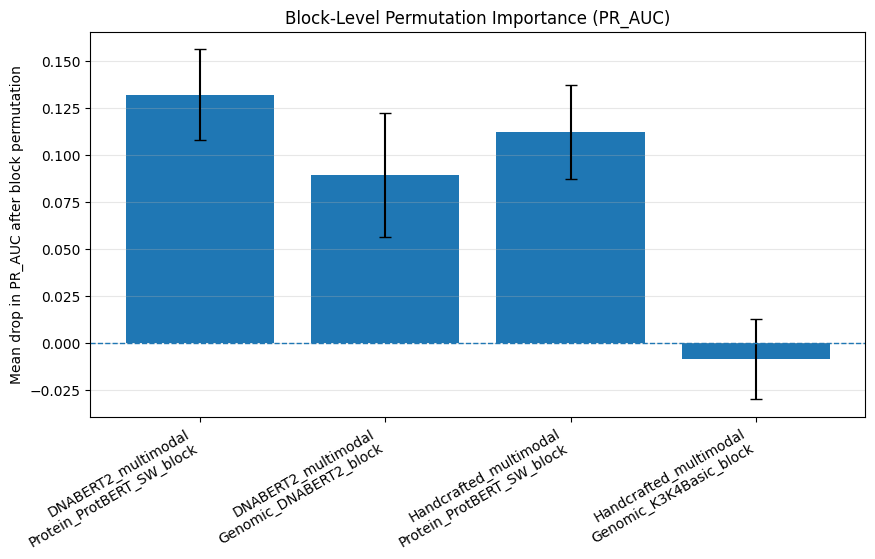

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_block_permutation_importance_pr_auc.png


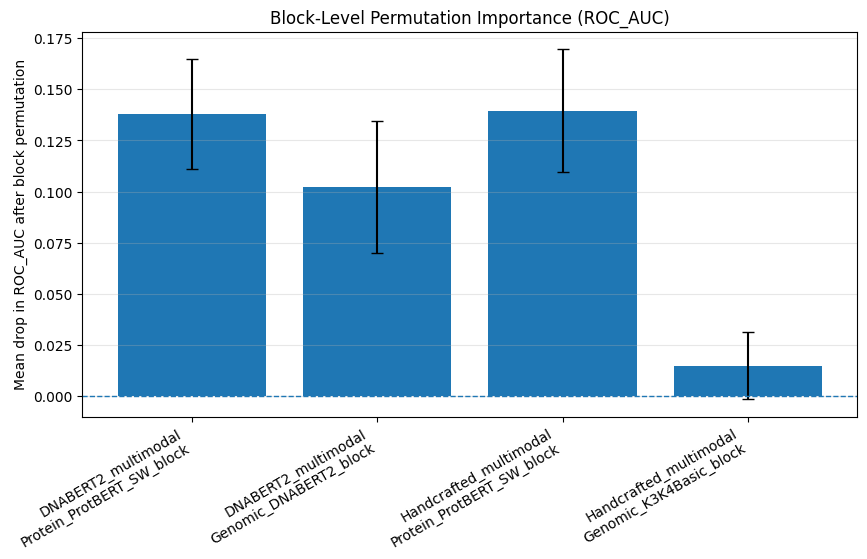

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_block_permutation_importance_roc_auc.png


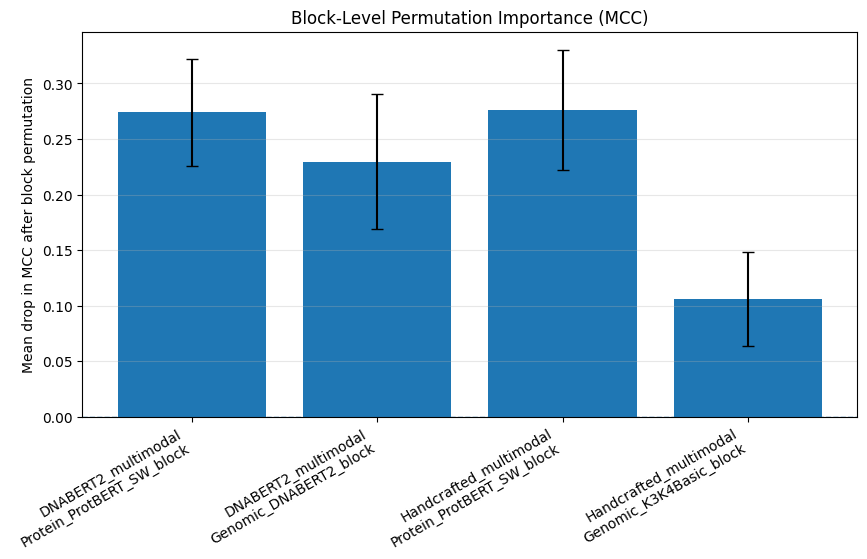

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_block_permutation_importance_mcc.png


In [27]:
# ============================================================
# FIGURE 1 — BLOCK PERMUTATION IMPORTANCE
# ============================================================

plot_df = block_importance_relative_df[
    block_importance_relative_df["metric"].isin(["pr_auc", "roc_auc", "mcc"])
].copy()

for metric in ["pr_auc", "roc_auc", "mcc"]:
    sub = plot_df[plot_df["metric"] == metric].copy()

    labels = sub["model"] + "\n" + sub["block_name"]
    x = np.arange(len(sub))

    plt.figure(figsize=(10, 5))
    plt.bar(x, sub["mean_drop"], yerr=sub["sd_drop"], capsize=4)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel(f"Mean drop in {metric.upper()} after block permutation")
    plt.title(f"Block-Level Permutation Importance ({metric.upper()})")
    plt.grid(axis="y", alpha=0.3)

    out_path = FIGURE_DIR / f"phase14_block_permutation_importance_{metric}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

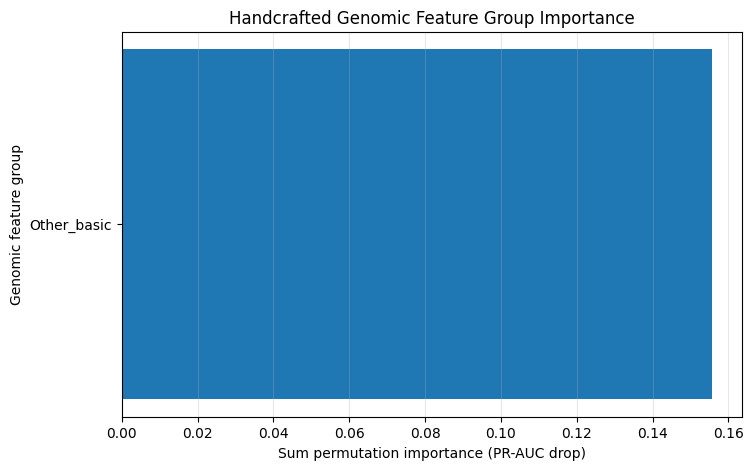

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_genomic_feature_group_permutation_importance.png


In [28]:
# ============================================================
# FIGURE 2 — GENOMIC FEATURE GROUP IMPORTANCE
# ============================================================

group_plot_df = group_importance_df.sort_values("sum_importance", ascending=True).copy()

plt.figure(figsize=(8, 5))
plt.barh(group_plot_df["feature_group"], group_plot_df["sum_importance"])
plt.xlabel("Sum permutation importance (PR-AUC drop)")
plt.ylabel("Genomic feature group")
plt.title("Handcrafted Genomic Feature Group Importance")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase14_genomic_feature_group_permutation_importance.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

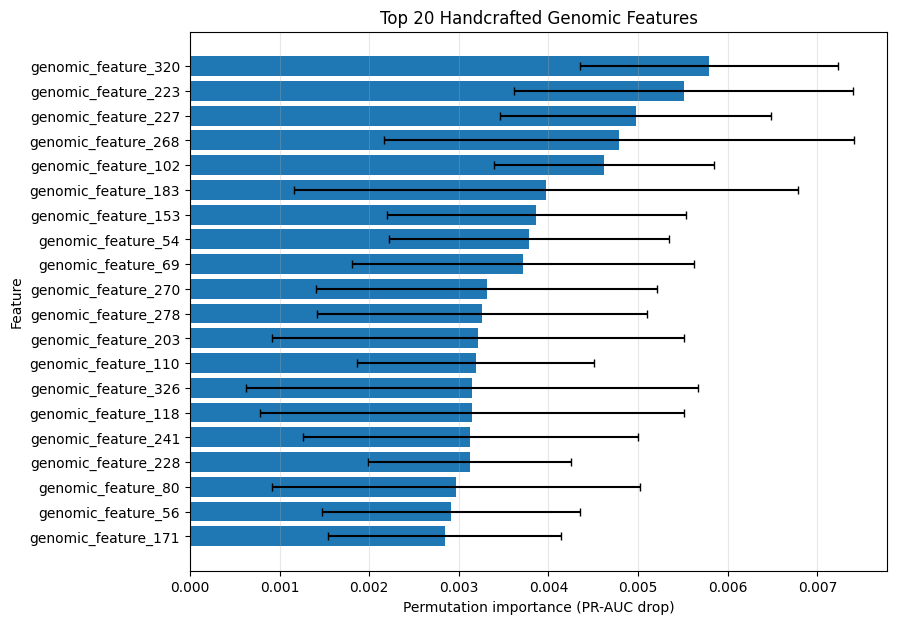

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_top20_genomic_feature_permutation_importance.png


In [29]:
# ============================================================
# FIGURE 3 — TOP GENOMIC FEATURES BY PERMUTATION IMPORTANCE
# ============================================================

TOP_N_FEATURES = 20

top_feat_df = feature_perm_df.head(TOP_N_FEATURES).sort_values(
    "importance_mean_pr_auc_drop",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_feat_df["feature_name"],
    top_feat_df["importance_mean_pr_auc_drop"],
    xerr=top_feat_df["importance_sd_pr_auc_drop"],
    capsize=3
)
plt.xlabel("Permutation importance (PR-AUC drop)")
plt.ylabel("Feature")
plt.title(f"Top {TOP_N_FEATURES} Handcrafted Genomic Features")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase14_top20_genomic_feature_permutation_importance.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

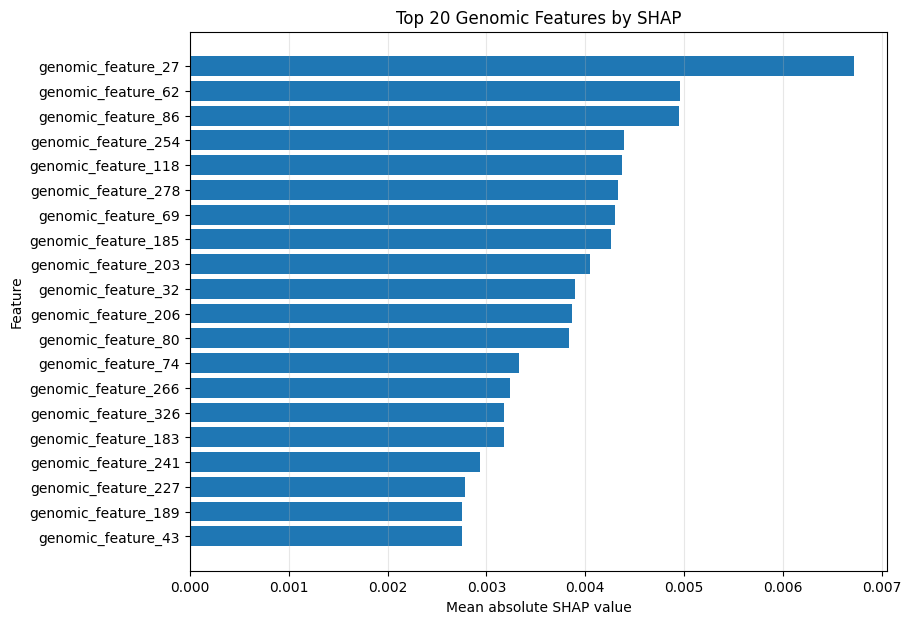

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_top20_genomic_feature_shap_importance.png


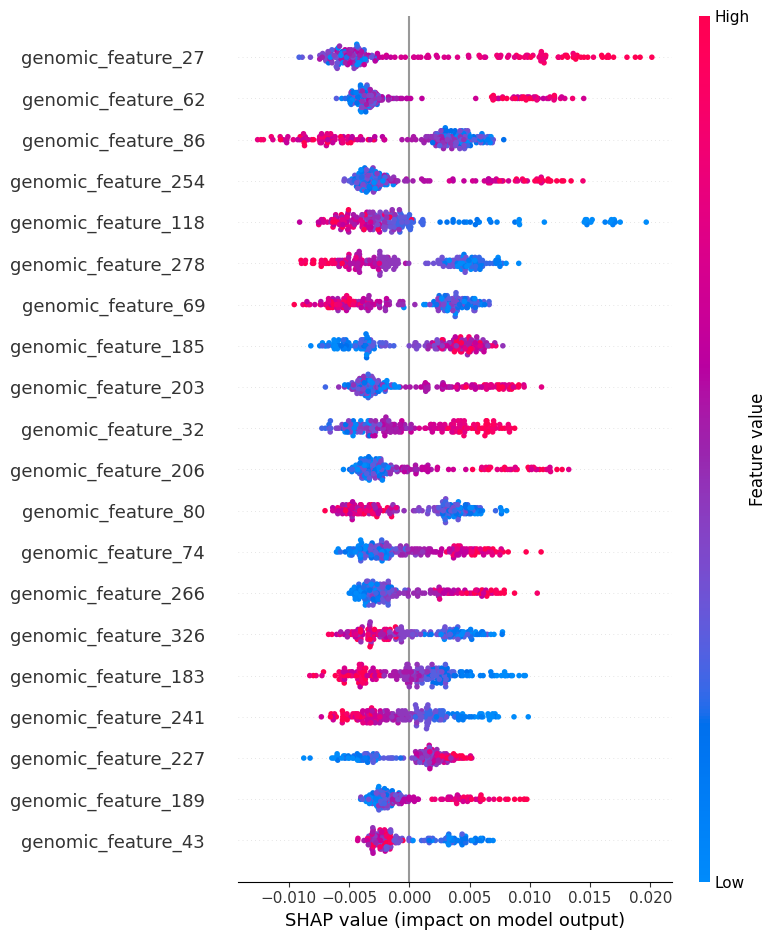

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_genomic_rf_shap_summary_plot.png


In [30]:
# ============================================================
# FIGURE 4 — SHAP BAR PLOT AND SUMMARY PLOT
# ============================================================

if shap_results_available:
    # Top SHAP bar plot
    top_shap_df = shap_feature_df.head(TOP_N_FEATURES).sort_values(
        "mean_abs_shap",
        ascending=True
    )

    plt.figure(figsize=(9, 7))
    plt.barh(top_shap_df["feature_name"], top_shap_df["mean_abs_shap"])
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Feature")
    plt.title(f"Top {TOP_N_FEATURES} Genomic Features by SHAP")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / "phase14_top20_genomic_feature_shap_importance.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

    # SHAP summary plot
    try:
        plt.figure()
        shap.summary_plot(
            shap_values_pos,
            X_shap,
            feature_names=genomic_feature_names,
            show=False,
            max_display=20
        )
        out_path = FIGURE_DIR / "phase14_genomic_rf_shap_summary_plot.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)

    except Exception as e:
        print("Could not create SHAP summary plot:", e)

else:
    print("SHAP results not available. Skipping SHAP figures.")

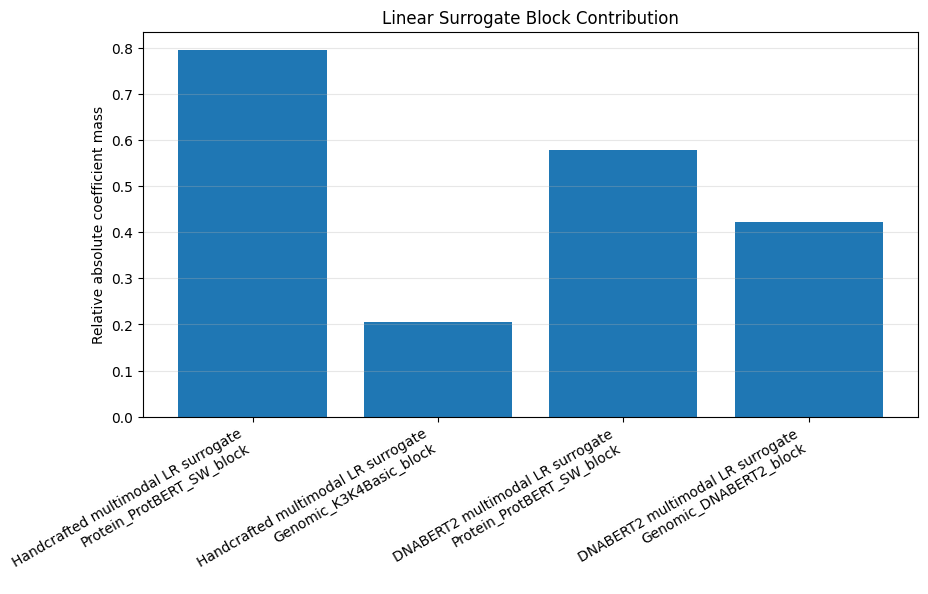

Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/figures/phase14_lr_surrogate_block_contribution.png


In [31]:
# ============================================================
# FIGURE 5 — LR SURROGATE BLOCK CONTRIBUTION
# ============================================================

lr_block_plot_df = pd.concat([
    hand_block_coef_summary_df.assign(model="Handcrafted multimodal LR surrogate"),
    dna_block_coef_summary_df.assign(model="DNABERT2 multimodal LR surrogate")
], ignore_index=True)

labels = lr_block_plot_df["model"] + "\n" + lr_block_plot_df["block"]
x = np.arange(len(lr_block_plot_df))

plt.figure(figsize=(10, 5))
plt.bar(x, lr_block_plot_df["relative_abs_coefficient"])
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Relative absolute coefficient mass")
plt.title("Linear Surrogate Block Contribution")
plt.grid(axis="y", alpha=0.3)

out_path = FIGURE_DIR / "phase14_lr_surrogate_block_contribution.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [32]:
# ============================================================
# EXPLAINABILITY CLAIMS TABLE
# ============================================================

claims = []

# Block permutation: summarize PR-AUC
pr_block = block_importance_relative_df[
    block_importance_relative_df["metric"] == "pr_auc"
].copy()

for _, row in pr_block.iterrows():
    claims.append({
        "analysis": "Block-level permutation importance",
        "model": row["model"],
        "finding": f"{row['block_name']} mean PR-AUC drop = {row['mean_drop']:.4f}",
        "interpretation": (
            "Higher drop indicates greater contribution to ranking performance. "
            "This supports modality-level explainability by quantifying protein vs genomic block dependence."
        )
    })

# Genomic feature group
if not group_importance_df.empty:
    top_group = group_importance_df.iloc[0]
    claims.append({
        "analysis": "Genomic handcrafted feature-group importance",
        "model": "Genomic RF explainability model",
        "finding": (
            f"Top feature group by permutation importance: {top_group['feature_group']} "
            f"(sum importance = {top_group['sum_importance']:.4f})"
        ),
        "interpretation": (
            "This identifies which type of handcrafted genomic sequence feature contributes most to the genomic model."
        )
    })

# SHAP group
if shap_results_available and not shap_group_df.empty:
    top_shap_group = shap_group_df.iloc[0]
    claims.append({
        "analysis": "SHAP genomic feature-group importance",
        "model": "Genomic RF explainability model",
        "finding": (
            f"Top SHAP group: {top_shap_group['feature_group']} "
            f"(relative SHAP importance = {top_shap_group['relative_group_shap_importance']:.4f})"
        ),
        "interpretation": (
            "SHAP provides an additional model-based explanation of which handcrafted genomic feature groups drive predictions."
        )
    })

# LR surrogate
for _, row in hand_block_coef_summary_df.iterrows():
    claims.append({
        "analysis": "Linear surrogate coefficient analysis",
        "model": "Handcrafted multimodal LR surrogate",
        "finding": (
            f"{row['block']} relative coefficient mass = {row['relative_abs_coefficient']:.4f}"
        ),
        "interpretation": (
            "The surrogate provides a transparent approximation of global modality contribution."
        )
    })

phase14_claims_df = pd.DataFrame(claims)
phase14_claims_df = round_numeric_columns(phase14_claims_df, 4)

display(phase14_claims_df)

save_dataframe(
    phase14_claims_df,
    RESULT_DIR / "phase14_explainability_claims_for_manuscript.csv"
)

,analysis,model,finding,interpretation
0,Block-level permutation importance,DNABERT2_multimodal,Protein_ProtBERT_SW_block mean PR-AUC drop = 0.1320,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
1,Block-level permutation importance,DNABERT2_multimodal,Genomic_DNABERT2_block mean PR-AUC drop = 0.0894,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
2,Block-level permutation importance,Handcrafted_multimodal,Protein_ProtBERT_SW_block mean PR-AUC drop = 0.1120,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
3,Block-level permutation importance,Handcrafted_multimodal,Genomic_K3K4Basic_block mean PR-AUC drop = -0.0084,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
4,Genomic handcrafted feature-group importance,Genomic RF explainability model,Top feature group by permutation importance: Other_basic (sum importance = 0.1557),This identifies which type of handcrafted genomic sequence feature contributes most to the genomic model.
5,SHAP genomic feature-group importance,Genomic RF explainability model,Top SHAP group: Other_basic (relative SHAP importance = 1.0000),SHAP provides an additional model-based explanation of which handcrafted genomic feature groups drive predictions.
6,Linear surrogate coefficient analysis,Handcrafted multimodal LR surrogate,Protein_ProtBERT_SW_block relative coefficient mass = 0.7948,The surrogate provides a transparent approximation of global modality contribution.
7,Linear surrogate coefficient analysis,Handcrafted multimodal LR surrogate,Genomic_K3K4Basic_block relative coefficient mass = 0.2052,The surrogate provides a transparent approximation of global modality contribution.


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_explainability_claims_for_manuscript.csv


In [33]:
# ============================================================
# MANUSCRIPT-READY WORDING FOR EXPLAINABILITY
# ============================================================

methods_text = """
Explainability analysis was added to complement the biological validation. Because the main multimodal models included high-dimensional protein and genomic representations, two levels of explainability were evaluated. First, block-level permutation importance was used to quantify the contribution of the protein and genomic modality blocks. For each trained multimodal model, the protein block and genomic block were permuted separately on the test set, and the resulting decrease in PR-AUC, ROC-AUC, MCC and F1 was recorded. This analysis provided modality-level interpretability by estimating how strongly each model depended on protein versus genomic information.

Second, feature-level explainability was performed for the handcrafted genomic representation. A random forest explainability model was trained on the K3/K4/Basic genomic features, and feature-level permutation importance was computed using PR-AUC as the scoring function. Features were grouped into interpretable categories, including GC content, CpG-related features, skew features, nucleotide-composition features, K3 k-mers and K4 k-mers. SHAP TreeExplainer was also applied to the genomic random forest model where computationally feasible. Mean absolute SHAP values were used to identify the most influential handcrafted genomic features and feature groups. These analyses were intended to justify the explainable component of the framework by linking model behaviour to modality blocks and interpretable genomic sequence features.
""".strip()

results_text = """
The explainability analysis supported the earlier conclusion that protein embeddings provide the dominant predictive signal while genomic features contribute complementary information. In the multimodal models, block-level permutation importance quantified the performance drop caused by separately disrupting the protein and genomic feature blocks. A larger performance drop after protein block permutation indicated stronger dependence on protein embeddings, whereas a smaller but non-zero drop after genomic block permutation indicated complementary genomic contribution.

For the handcrafted genomic features, feature-level permutation importance and SHAP analysis identified which sequence feature groups contributed most to the genomic explainability model. Grouped feature importance allowed the genomic signal to be interpreted in terms of compositional and k-mer-based sequence patterns rather than anonymous high-dimensional embeddings. This strengthened the explainability component of the framework because the handcrafted genomic representation could be related back to explicit sequence properties such as k-mer composition, GC/CpG content and sequence skew.

Overall, the explainability results should be interpreted as global model-behaviour evidence rather than mechanistic proof. They show that the framework can quantify modality-level dependence and identify influential interpretable genomic feature groups, thereby supporting the use of the term explainable in the study title. However, because protein and DNABERT-2 embeddings remain high-dimensional latent representations, biological validation and literature-supported interpretation of top-ranked genes remain necessary complements to feature-attribution analysis.
""".strip()

discussion_text = """
The explainability analysis clarifies why genomic information remains useful despite modest performance gains. The protein block contributed most strongly to predictive ranking, consistent with the superior protein-only baseline. However, genomic feature perturbation still produced measurable changes in performance, and handcrafted genomic features improved specificity and biological interpretability in the multimodal setting. This suggests that genomic information should not be judged only by whether it produces large aggregate metric gains. In gene prioritization, a modality may be valuable if it improves false-positive control, contributes interpretable regulatory context or changes the biological composition of the top-ranked candidate list.

The explainability results also highlight a difference between handcrafted genomic features and DNABERT-2 embeddings. Handcrafted features are less powerful as standalone predictors but are more directly interpretable because they correspond to explicit sequence properties such as k-mer frequencies and compositional features. DNABERT-2 embeddings may capture richer contextual sequence information, but their dimensions are less directly interpretable. This reinforces the central ranking-versus-interpretability theme of the study.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Explainability Analysis", "text": methods_text},
    {"section": "Results - Explainability Analysis", "text": results_text},
    {"section": "Discussion - Explainability Interpretation", "text": discussion_text},
])

display(wording_df)

save_dataframe(
    wording_df,
    RESULT_DIR / "phase14_manuscript_ready_explainability_wording.csv"
)

with open(REPORT_DIR / "phase14_explainability_methods_results_discussion_text.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Explainability Analysis,"Explainability analysis was added to complement the biological validation. Because the main multimodal models included high-dimensional protein and genomic representations, two levels of explainability were evaluated. First, block-level permutation importance was used to quantify the contributio..."
1,Results - Explainability Analysis,"The explainability analysis supported the earlier conclusion that protein embeddings provide the dominant predictive signal while genomic features contribute complementary information. In the multimodal models, block-level permutation importance quantified the performance drop caused by separate..."
2,Discussion - Explainability Interpretation,"The explainability analysis clarifies why genomic information remains useful despite modest performance gains. The protein block contributed most strongly to predictive ranking, consistent with the superior protein-only baseline. However, genomic feature perturbation still produced measurable ch..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_manuscript_ready_explainability_wording.csv
Saved manuscript wording.


In [34]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase14_explainability_analysis_tables.xlsx"

excel_tables = {
    "Model_Evaluation": explainability_model_eval_df,
    "Block_Importance": block_importance_relative_df,
    "Genomic_Feature_Info": genomic_feature_info_df,
    "Feature_Permutation": feature_perm_df,
    "Group_Permutation": group_importance_df,
    "Hand_LR_Coefficients": hand_coef_df.head(500),
    "DNA_LR_Coefficients": dna_coef_df.head(500),
    "Hand_Block_Coef": hand_block_coef_summary_df,
    "Hand_Group_Coef": hand_group_coef_summary_df,
    "DNA_Block_Coef": dna_block_coef_summary_df,
    "DNA_Group_Coef": dna_group_coef_summary_df,
    "Claims": phase14_claims_df,
    "Wording": wording_df,
}

if shap_results_available:
    excel_tables["SHAP_Feature"] = shap_feature_df
    excel_tables["SHAP_Group"] = shap_group_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/excel/phase14_explainability_analysis_tables.xlsx


In [35]:
# ============================================================
# FINAL SUMMARY AND OUTPUT LIST
# ============================================================

print("=== PHASE 14 COMPLETE ===")

print("\nKey result files:")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 14 COMPLETE ===

Key result files:
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_combined_relative.csv
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_dnabert2_multimodal.csv
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_handcrafted_multimodal.csv
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_dnabert2_multimodal_lr_block_coefficient_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_dnabert2_multimodal_lr_group_coefficient_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_dnabert2_multimodal_lr_surrogate_coefficients.csv
/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/resu

In [36]:
display(explainability_model_eval_df)
display(block_importance_relative_df)
display(group_importance_df)
display(feature_perm_df.head(30))

if shap_results_available:
    display(shap_group_df)
    display(shap_feature_df.head(30))

display(phase14_claims_df)
display(wording_df)

,model_name,validation_selected_threshold,validation_mcc_at_threshold,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp,threshold
0,Genomic_RF_explainability,0.4859,0.2629,0.6237,0.6432,0.6052,0.6167,0.5481,0.6618,0.5804,0.2113,90,46,61,74,0.4859
1,Handcrafted_multimodal_LR_surrogate,0.0080,0.2903,0.6399,0.6161,0.5756,0.5463,0.8741,0.2794,0.6724,0.1908,38,98,17,118,0.0080
2,DNABERT2_multimodal_LR_surrogate,0.9570,0.2267,0.6930,0.6790,0.6494,0.7174,0.4889,0.8088,0.5815,0.3143,110,26,69,66,0.9570
3,Handcrafted_multimodal_primary_for_block,0.0080,0.2903,0.6399,0.6161,0.5756,0.5463,0.8741,0.2794,0.6724,0.1908,38,98,17,118,0.0080
4,DNABERT2_multimodal_primary_for_block,0.9570,0.2267,0.6930,0.6790,0.6494,0.7174,0.4889,0.8088,0.5815,0.3143,110,26,69,66,0.9570


,metric,block_name,base_metric,mean_drop,sd_drop,min_drop,max_drop,n_repeats,drop_values,model,relative_importance_within_metric
0,f1,Protein_ProtBERT_SW_block,0.574074,0.135885,0.029412,0.067407,0.183165,30,0.165185;0.116675;0.128659;0.118717;0.159660;0.105048;0.142356;0.146724;0.148148;0.174074;0.133707;0.100860;0.147987;0.140446;0.138519;0.158145;0.170404;0.112536;0.181380;0.151167;0.084991;0.107114;0.108321;0.111852;0.183165;0.104509;0.164983;0.163360;0.140446;0.067407,DNABERT2_multimodal,0.520604
1,f1,Genomic_DNABERT2_block,0.574074,0.125129,0.036408,0.060313,0.210438,30,0.114615;0.102458;0.160929;0.146801;0.130635;0.071791;0.155026;0.113980;0.060313;0.150651;0.132760;0.087588;0.110438;0.163115;0.132760;0.164550;0.094811;0.166491;0.121244;0.210438;0.115358;0.186687;0.107114;0.096597;0.112536;0.062863;0.113980;0.097010;0.170404;0.099936,DNABERT2_multimodal,0.479396
2,mcc,Protein_ProtBERT_SW_block,0.349028,0.274091,0.048307,0.158385,0.338581,30,0.330756;0.236147;0.284317;0.244303;0.306972;0.229202;0.299627;0.338565;0.257949;0.298101;0.242506;0.212874;0.323116;0.291710;0.283746;0.322964;0.306549;0.219663;0.330597;0.315212;0.206791;0.237286;0.202935;0.236735;0.338581;0.245780;0.306768;0.322876;0.291710;0.158385,DNABERT2_multimodal,0.544062
3,mcc,Genomic_DNABERT2_block,0.349028,0.229695,0.060623,0.114419,0.386299,30,0.227934;0.237801;0.265179;0.274956;0.251375;0.139104;0.239523;0.183675;0.114419;0.291164;0.216276;0.180512;0.211331;0.298682;0.216276;0.256018;0.169877;0.264580;0.191246;0.386299;0.210484;0.354395;0.237286;0.196319;0.219663;0.141585;0.183675;0.178462;0.306549;0.246207,DNABERT2_multimodal,0.455938
4,pr_auc,Protein_ProtBERT_SW_block,0.679013,0.131990,0.024160,0.066782,0.168860,30,0.145656;0.123598;0.125024;0.135187;0.158155;0.121739;0.144433;0.147011;0.118894;0.101045;0.124794;0.137144;0.154312;0.124086;0.147686;0.136728;0.123759;0.151974;0.137888;0.167325;0.138088;0.168860;0.066782;0.112960;0.111249;0.092967;0.166588;0.138360;0.151114;0.086306,DNABERT2_multimodal,0.596263
5,pr_auc,Genomic_DNABERT2_block,0.679013,0.089372,0.032968,0.028428,0.160109,30,0.078043;0.077125;0.110189;0.116571;0.066492;0.075884;0.049892;0.076018;0.028428;0.109836;0.063029;0.067473;0.103537;0.128548;0.113464;0.107869;0.064799;0.103288;0.058744;0.155600;0.097146;0.160109;0.112635;0.086696;0.063367;0.081234;0.040851;0.049330;0.146181;0.088783,DNABERT2_multimodal,0.403737
6,roc_auc,Protein_ProtBERT_SW_block,0.693028,0.138148,0.026893,0.064434,0.207571,30,0.132571;0.125599;0.123420;0.116885;0.141176;0.115033;0.141558;0.170915;0.150381;0.135294;0.110893;0.125490;0.161438;0.133660;0.125218;0.164651;0.140523;0.122168;0.161765;0.207571;0.145915;0.169390;0.064434;0.142102;0.133224;0.109477;0.173257;0.152070;0.148747;0.099619,DNABERT2_multimodal,0.574523
7,roc_auc,Genomic_DNABERT2_block,0.693028,0.102309,0.032294,0.039379,0.175817,30,0.078050;0.113725;0.133769;0.109641;0.089434;0.067810;0.080719;0.091013;0.039379;0.130991;0.081100;0.101416;0.104303;0.130719;0.132898;0.113943;0.069281;0.132081;0.070697;0.175817;0.102996;0.160294;0.114597;0.100000;0.084150;0.059913;0.063181;0.078431;0.159586;0.099346,DNABERT2_multimodal,0.425477
8,f1,Protein_ProtBERT_SW_block,0.647482,0.134899,0.027713,0.079137,0.189917,30,0.149314;0.170948;0.079137;0.117016;0.138648;0.111768;0.127909;0.147482;0.140440;0.149261;0.176468;0.127335;0.131581;0.120009;0.143832;0.167482;0.151186;0.094755;0.185944;0.117865;0.156507;0.131353;0.106741;0.092322;0.132776;0.120009;0.189917;0.089991;0.136844;0.142144,Handcrafted_multimodal,0.752004
9,f1,Genomic_K3K4Basic_block,0.647482,0.044487,0.021900,0.005844,0.089991,30,0.031540;0.022482;0.029938;0.026792;0.005844;0.089991;0.032641;0.072043;0.021147;0.057554;0.081174;0.042500;0.034806;0.072140;0.048890;0.018111;0.015180;0.064748;0.037553;0.040585;0.038485;0.084305;0.069704;0.039090;0.048179;0.048179;0.030461;0.064456;0.040984;0.025104,Handcrafted_multimodal,0.247996


,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance
0,Other_basic,356,0.155725,0.000437,0.00579,1.0


,feature_index,feature_name,feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop
0,320,genomic_feature_320,Other_basic,0.005790,0.001438
1,223,genomic_feature_223,Other_basic,0.005506,0.001896
2,227,genomic_feature_227,Other_basic,0.004972,0.001508
3,268,genomic_feature_268,Other_basic,0.004788,0.002622
4,102,genomic_feature_102,Other_basic,0.004619,0.001228
5,183,genomic_feature_183,Other_basic,0.003970,0.002812
6,153,genomic_feature_153,Other_basic,0.003866,0.001666
7,54,genomic_feature_54,Other_basic,0.003782,0.001563
8,69,genomic_feature_69,Other_basic,0.003719,0.001908
9,270,genomic_feature_270,Other_basic,0.003311,0.001901


,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance
0,Other_basic,356,0.354955,0.000997,0.006722,1.0


,feature_index,feature_name,feature_group,mean_abs_shap
0,27,genomic_feature_27,Other_basic,0.006722
1,62,genomic_feature_62,Other_basic,0.004957
2,86,genomic_feature_86,Other_basic,0.004953
3,254,genomic_feature_254,Other_basic,0.004394
4,118,genomic_feature_118,Other_basic,0.004373
5,278,genomic_feature_278,Other_basic,0.004334
6,69,genomic_feature_69,Other_basic,0.004297
7,185,genomic_feature_185,Other_basic,0.004262
8,203,genomic_feature_203,Other_basic,0.004047
9,32,genomic_feature_32,Other_basic,0.003898


,analysis,model,finding,interpretation
0,Block-level permutation importance,DNABERT2_multimodal,Protein_ProtBERT_SW_block mean PR-AUC drop = 0.1320,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
1,Block-level permutation importance,DNABERT2_multimodal,Genomic_DNABERT2_block mean PR-AUC drop = 0.0894,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
2,Block-level permutation importance,Handcrafted_multimodal,Protein_ProtBERT_SW_block mean PR-AUC drop = 0.1120,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
3,Block-level permutation importance,Handcrafted_multimodal,Genomic_K3K4Basic_block mean PR-AUC drop = -0.0084,Higher drop indicates greater contribution to ranking performance. This supports modality-level explainability by quantifying protein vs genomic block dependence.
4,Genomic handcrafted feature-group importance,Genomic RF explainability model,Top feature group by permutation importance: Other_basic (sum importance = 0.1557),This identifies which type of handcrafted genomic sequence feature contributes most to the genomic model.
5,SHAP genomic feature-group importance,Genomic RF explainability model,Top SHAP group: Other_basic (relative SHAP importance = 1.0000),SHAP provides an additional model-based explanation of which handcrafted genomic feature groups drive predictions.
6,Linear surrogate coefficient analysis,Handcrafted multimodal LR surrogate,Protein_ProtBERT_SW_block relative coefficient mass = 0.7948,The surrogate provides a transparent approximation of global modality contribution.
7,Linear surrogate coefficient analysis,Handcrafted multimodal LR surrogate,Genomic_K3K4Basic_block relative coefficient mass = 0.2052,The surrogate provides a transparent approximation of global modality contribution.


,section,text
0,Methods - Explainability Analysis,"Explainability analysis was added to complement the biological validation. Because the main multimodal models included high-dimensional protein and genomic representations, two levels of explainability were evaluated. First, block-level permutation importance was used to quantify the contributio..."
1,Results - Explainability Analysis,"The explainability analysis supported the earlier conclusion that protein embeddings provide the dominant predictive signal while genomic features contribute complementary information. In the multimodal models, block-level permutation importance quantified the performance drop caused by separate..."
2,Discussion - Explainability Interpretation,"The explainability analysis clarifies why genomic information remains useful despite modest performance gains. The protein block contributed most strongly to predictive ranking, consistent with the superior protein-only baseline. However, genomic feature perturbation still produced measurable ch..."
